<a href="https://colab.research.google.com/github/Mohamedboukerche22/simple-llm/blob/main/pytorch/diabetes_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [412]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , accuracy_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from torch.utils.data import DataLoader , TensorDataset

In [413]:
X,y = load_diabetes(return_X_y=True)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [414]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [415]:
# to tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)

In [416]:
train_dataset = TensorDataset(X_train , y_train)

In [417]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

(torch.Size([353, 10]),
 torch.Size([353, 1]),
 torch.Size([89, 10]),
 torch.Size([89, 1]))

In [418]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True)

In [419]:
#model = LinearRegression()
#model.fit(X_train,y_train)
#ready_model_pred = model.predict(X_test)
#ready_model_score = r2_score(y_test,ready_model_pred)
#print("r2 score :" , ready_model_score)

In [420]:
 # plt.scatter(y_test,ready_model_pred)

In [421]:
class DiabetModel(nn.Module):

  def __init__(self):
    super().__init__()

    self.fc1 = nn.Linear(10,64)
    self.fc2 = nn.Linear(64,32)
    self.fc3 = nn.Linear(32,1)
    self.dropout = nn.Dropout(0.2)


  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    x = F.relu(self.fc2(x))
    x = self.dropout(x)

    x = self.fc3(x)

    return x

In [422]:
criterion = nn.MSELoss()
model = DiabetModel()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [423]:
# train
epoches = 1000

for epoch in range(epoches):
   pred = model(X_train)
   loss = criterion(pred,y_train)

   optimizer.zero_grad()

   loss.backward()

   optimizer.step()

   if epoch % 50 == 0: # print everything
    print(f"epoch : {epoch} => loss : {loss.item()}")

epoch : 0 => loss : 29611.91015625
epoch : 50 => loss : 28600.609375
epoch : 100 => loss : 24651.78515625
epoch : 150 => loss : 15528.9775390625
epoch : 200 => loss : 7937.0751953125
epoch : 250 => loss : 5770.00830078125
epoch : 300 => loss : 5430.37451171875
epoch : 350 => loss : 4773.44140625
epoch : 400 => loss : 4193.85595703125
epoch : 450 => loss : 4145.646484375
epoch : 500 => loss : 4140.1357421875
epoch : 550 => loss : 3803.646240234375
epoch : 600 => loss : 3490.22265625
epoch : 650 => loss : 3496.51123046875
epoch : 700 => loss : 3322.137451171875
epoch : 750 => loss : 3202.646240234375
epoch : 800 => loss : 3468.012451171875
epoch : 850 => loss : 3327.88818359375
epoch : 900 => loss : 3148.779296875
epoch : 950 => loss : 3204.629150390625


In [424]:
model.eval()

DiabetModel(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [425]:
with torch.no_grad():
  pred = model(X_test)
  loss = criterion(pred,y_test)
  print(loss.item())

2596.41259765625


In [426]:
pred = pred.numpy()

In [427]:
score = r2_score(y_test,pred)
print("r2 score :" , score)

r2 score : 0.5715508460998535


## epoches = 1000 => r2 score = 0.5715508460998535

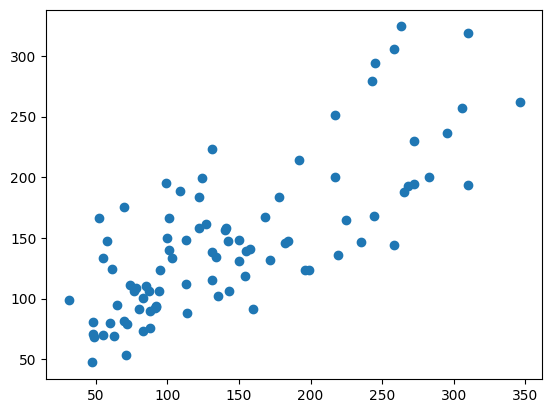

In [428]:
plt.scatter(y_test,pred)

# models from net
'not mine'

Ridge Regression R2 Score: 0.4192
Lasso Regression R2 Score: 0.4719
Gradient Boosting R2 Score: 0.4529


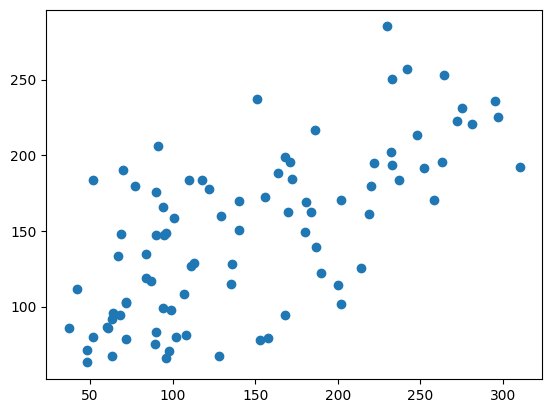

In [429]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
predictions = []
# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    print(f"{name} R2 Score: {r2:.4f}")

plt.scatter(y_test,predictions)

mine still better ig